In [2]:
from models.rdunet import RDUNet 

In [3]:
import torch
import importlib
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
import os
from pytorch_msssim import ssim
from torchmetrics.image import PeakSignalNoiseRatio
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device('mps' if  torch.backends.mps.is_available() else 'cpu')
print(device)

mps


In [5]:
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune, test_func, NoiseImage
from base import augment, test_func_batches, list_images, collect_images, augment_data


psnr_metric = PeakSignalNoiseRatio(data_range=1.0)
psnr_metric = psnr_metric.to(device)



In [6]:
import base
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune
importlib.reload(base)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0)

In [7]:
rdunet = RDUNet(**{'channels': 1, 'base filters': 128})
rdunet_model = rdunet.to(device)

# Load the .pth checkpoint
checkpoint = torch.load('/Users/tjsss/Desktop/bharatAtomic/semPhase1/model_weights/model_gray.pth', map_location=device)

# Handle two common .pth formats:
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    rdunet_model.load_state_dict(checkpoint['model_state_dict'])
else:
    rdunet_model.load_state_dict(checkpoint)

print("Pretrained weights loaded successfully!")

Pretrained weights loaded successfully!


In [8]:
for name, param in rdunet_model.named_parameters():
    print(f"{name}")

input_block.conv_1.weight
input_block.conv_1.bias
input_block.conv_2.weight
input_block.conv_2.bias
input_block.actv_1.weight
input_block.actv_2.weight
block_0_0.conv_0.weight
block_0_0.conv_0.bias
block_0_0.conv_1.weight
block_0_0.conv_1.bias
block_0_0.conv_2.weight
block_0_0.conv_2.bias
block_0_0.conv_3.weight
block_0_0.conv_3.bias
block_0_0.actv_0.weight
block_0_0.actv_1.weight
block_0_0.actv_2.weight
block_0_0.actv_3.weight
block_0_1.conv_0.weight
block_0_1.conv_0.bias
block_0_1.conv_1.weight
block_0_1.conv_1.bias
block_0_1.conv_2.weight
block_0_1.conv_2.bias
block_0_1.conv_3.weight
block_0_1.conv_3.bias
block_0_1.actv_0.weight
block_0_1.actv_1.weight
block_0_1.actv_2.weight
block_0_1.actv_3.weight
down_0.conv.weight
down_0.conv.bias
down_0.actv.weight
block_1_0.conv_0.weight
block_1_0.conv_0.bias
block_1_0.conv_1.weight
block_1_0.conv_1.bias
block_1_0.conv_2.weight
block_1_0.conv_2.bias
block_1_0.conv_3.weight
block_1_0.conv_3.bias
block_1_0.actv_0.weight
block_1_0.actv_1.weight
b

In [9]:
to_freeze = ['block_3_1.',
'block_3_0.',
'block_2_1.',
'block_2_0.',
'down_2.',
'block_1_1.',
'block_1_0.',
'down_1.',
'block_0_1.',
'block_0_0.',
'down_0',
'input_block.',
'block_2_2',
'block_3_2.',
'block_3_3.',
'up_2.',]


In [10]:
for name, param in rdunet_model.named_parameters():
    if any(name.startswith(l) for l in to_freeze):
        param.requires_grad = False
    else:
        param.requires_grad = True

print("After freezing encoder layers:")
print(f" {'-'*40} \n FROZEN PARAMS \n {'-'*40}")
for name, param in rdunet_model.named_parameters():
    if not param.requires_grad:
        print(f"  {name}: {param.shape} --- {param.requires_grad}")

print(f"{'-'*40} \n TRAINABLE PARAMS \n {'-'*40}")
for name, param in rdunet_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.shape} --- {param.requires_grad}")


After freezing encoder layers:
 ---------------------------------------- 
 FROZEN PARAMS 
 ----------------------------------------
  input_block.conv_1.weight: torch.Size([128, 1, 3, 3]) --- False
  input_block.conv_1.bias: torch.Size([128]) --- False
  input_block.conv_2.weight: torch.Size([128, 128, 3, 3]) --- False
  input_block.conv_2.bias: torch.Size([128]) --- False
  input_block.actv_1.weight: torch.Size([128]) --- False
  input_block.actv_2.weight: torch.Size([128]) --- False
  block_0_0.conv_0.weight: torch.Size([64, 128, 3, 3]) --- False
  block_0_0.conv_0.bias: torch.Size([64]) --- False
  block_0_0.conv_1.weight: torch.Size([64, 192, 3, 3]) --- False
  block_0_0.conv_1.bias: torch.Size([64]) --- False
  block_0_0.conv_2.weight: torch.Size([64, 256, 3, 3]) --- False
  block_0_0.conv_2.bias: torch.Size([64]) --- False
  block_0_0.conv_3.weight: torch.Size([128, 320, 3, 3]) --- False
  block_0_0.conv_3.bias: torch.Size([128]) --- False
  block_0_0.actv_0.weight: torch.Size([6

In [11]:
parent_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/dataset/crop/images'
all_images = collect_images(parent_dir)
np.random.shuffle(all_images)

Total number of images collected: 18577
Shape of the first image: (299, 299, 3)
Type of the first image: <class 'numpy.ndarray'>


In [12]:
train_arrays = all_images[:int(len(all_images)*.70)]
test_arrays = all_images[int(len(all_images)*.70 ):]

In [13]:
noise_obj = NoiseImage()
train_dataset = CustomData(train_arrays, transform= transform_1(256), repeats = 5 , training = True , noise_obj = noise_obj)
test_dataset = CustomData(test_arrays , transform = transform_1(256), repeats = 1, training = False, noise_obj = noise_obj)

train_loader, val_loader, test_loader = load_data(train_dataset, test_dataset, batch_size = 4)

In [14]:
(x,y) = next(iter(train_loader))
x.shape

torch.Size([4, 1, 256, 256])

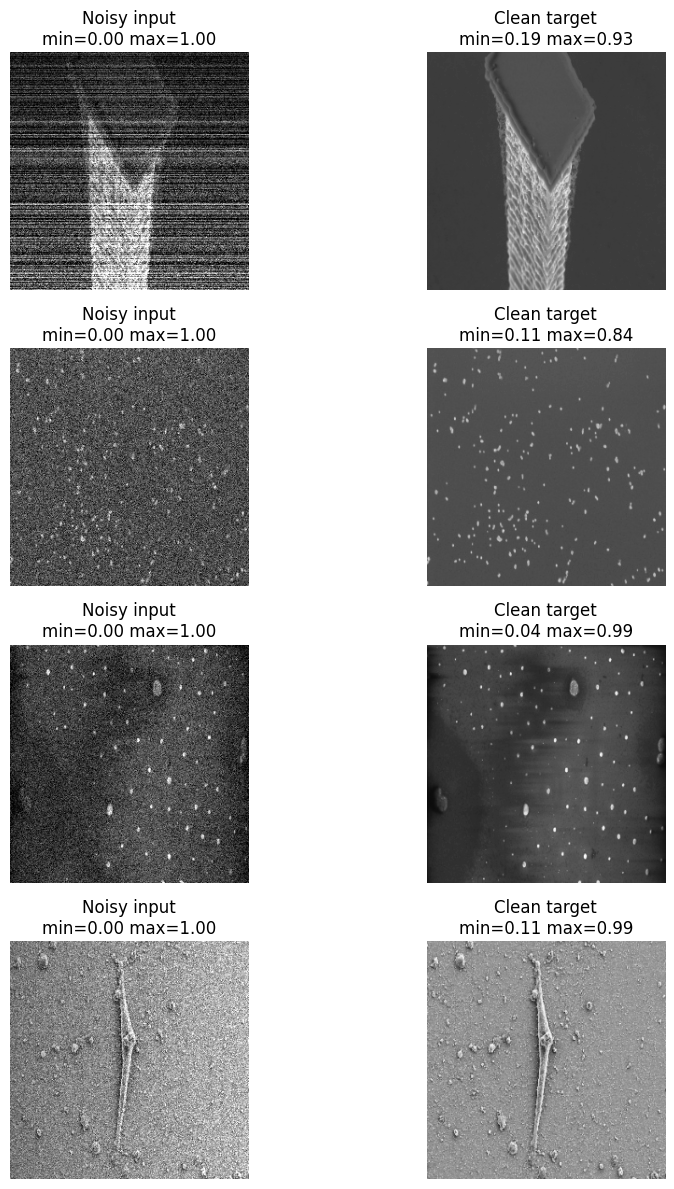

In [15]:
xt, yt = next((iter(train_loader)))
xt, yt = xt.to(device), yt.to(device)


# Move to CPU for plotting
xt_np   = xt.cpu().numpy()
yt_np   = yt.cpu().numpy()





# Plot first 4 images in the batch
n = min(4, xt.shape[0])
fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for i in range(n):
    # Handle both (C,H,W) grayscale and RGB
    def to_img(t):
        img = t[i]
        if img.shape[0] == 1:
            return img[0]          # (H, W)
        return img.transpose(1,2,0)  # (H, W, C)

    axes[i, 0].imshow(to_img(xt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Noisy input\nmin={xt_np[i].min():.2f} max={xt_np[i].max():.2f}")
    axes[i, 0].axis('off')


    axes[i, 1].imshow(to_img(yt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Clean target\nmin={yt_np[i].min():.2f} max={yt_np[i].max():.2f}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()



In [16]:
device

device(type='mps')

In [ ]:
fineTune(rdunet_model, train_loader , val_loader, num_epochs = 10, name='rdunet_finetuned_10_augData.pth', device = device)

x range: [0.000, 1.000]
y range: [0.014, 1.000]
  Batch 10/13003 | Loss: 0.20179150 57
 PSNR: 22.968975067138672
  Batch 20/13003 | Loss: 0.11296567 75
 PSNR: 19.812747955322266
  Batch 30/13003 | Loss: 0.16860668 83
 PSNR: 20.6656494140625
  Batch 40/13003 | Loss: 0.10734596 94
 PSNR: 29.1842041015625
  Batch 50/13003 | Loss: 0.14210865 64
 PSNR: 23.18096160888672
  Batch 60/13003 | Loss: 0.08576877 065
 PSNR: 25.252870559692383
  Batch 70/13003 | Loss: 0.18145631 37
 PSNR: 20.29294204711914
  Batch 80/13003 | Loss: 0.08504796 07
 PSNR: 24.637235641479492
  Batch 90/13003 | Loss: 0.13207653 86
 PSNR: 19.632478713989258
  Batch 100/13003 | Loss: 0.12506475 27
 PSNR: 25.779752731323242
  Batch 110/13003 | Loss: 0.14286610 35
 PSNR: 21.515756607055664
  Batch 120/13003 | Loss: 0.12927286 23
 PSNR: 21.260604858398438
  Batch 130/13003 | Loss: 0.11251251 66
 PSNR: 22.64729881286621
  Batch 140/13003 | Loss: 0.08471532 81
 PSNR: 24.78125
  Batch 150/13003 | Loss: 0.11014058 91
 PSNR: 24.254